# Data project: inequality 
This assignment examines income inequality in Denmark. To study this we retrieve the viariables income share and the gini-coefficient from statistikbanken.
 
## Overview

1. inequality in Denmark 
   - 1.1 Gini coefficinet and top 10% income share
   - 1.2 Prediction 
   - 1.3 Municipalities 
   - 1.4 Extension 
2. Simulating the income distibution 



In [ ]:


import pandas as pd 
import matplotlib.pyplot as plt 
from dstapi import DstApi
import numpy as np
from scipy.optimize import minimize

print("loading data from Statistikbanken")
IFOR41 = DstApi("IFOR41") 
IFOR32 = DstApi("IFOR32")

IFOR41.tablesummary(language="da")
IFOR32.tablesummary(language="da")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

loading data from Statistikbanken
Table IFOR41: Indkomstfordeling målt på ækvivaleret disponibel indkomst efter enhed, kommune og tid
Last update: 2025-12-01T08:00:00
Table IFOR32: Gennemsnitlig ækvivalret disponibel indkomst efter decilgennemsnit, kommune og tid
Last update: 2025-12-01T08:00:00


## Inequality in Denmark. 

### 1.1 Gini coefficinet and top 10% income share

the Gini coefficinet for all of Denmark is retrived for table IFOR41 from Danmarks statistik. Income for 10 deciles are retrived from table IFOR32 from Danmarks statistik. The top 10% income share is calculated by deviding decile 10 with toalt sums of all 10 deciles. 



In [2]:
print("Retrieving the Gini-coeficient for Danmark") 
gini_params = {
    "table": "IFOR41",
    "format": "BULK",
    "lang": "da",
    "variables":[
        {"code": "ULLIG", "values": ["70"]}, 
        {"code": "KOMMUNEDK", "values": ["000"]}, 
        {"code": "Tid", "values": ["*"]}
    ]
}

gini = IFOR41.get_data(params=gini_params)

gini["TID"] = pd.to_numeric(gini["TID"])
gini["INDHOLD"] = pd.to_numeric(gini["INDHOLD"])

gini_table = gini.rename(columns = {"TID": "ÅR", "INDHOLD": "Gini"})
gini_table = gini_table[["ÅR", "Gini"]].sort_values("ÅR", ascending = True)
display(gini_table.style.hide(axis="index"))

Retrieving the Gini-coeficient for Danmark


ÅR,Gini
1987,22.070000
1988,22.060000
1989,21.930000
1990,22.160000
1991,21.990000
1992,22.340000
1993,22.790000
1994,22.500000
1995,22.410000
1996,22.830000


In [3]:

print("retrieving the deciles for Danmark")
table_params = {
    "table": "IFOR32",
    "format": "BULK",
    "lang": "da",
    "variables":[
        {"code": "DECILGEN", "values": ["*"]},
        {"code": "KOMMUNEDK", "values": ["000"]},
        {"code": "Tid", "values": ["*"]}
    ]
}

deciles = IFOR32.get_data(params=table_params)

deciles["TID"] = pd.to_numeric(deciles["TID"])
deciles["INDHOLD"] = pd.to_numeric(deciles["INDHOLD"])


deciles_table = deciles.pivot(index ="TID", columns = "DECILGEN", values = "INDHOLD").reset_index()


deciles_table = deciles_table.rename(columns = {"TID": "ÅR"})


decile_order = [
    "ÅR",
    "1. decil",
    "2. decil",
    "3. decil",
    "4. decil",
    "5. decil",
    "6. decil",
    "7. decil",
    "8. decil",
    "9. decil",
    "10. decil"
]

deciles_table = deciles_table[decile_order]

display(deciles_table.style.hide(axis="index"))

retrieving the deciles for Danmark


ÅR,1. decil,2. decil,3. decil,4. decil,5. decil,6. decil,7. decil,8. decil,9. decil,10. decil
1987,31418,59014,68786,77577,85361,92777,100691,110184,123582,169598
1988,32746,62506,72540,81673,89941,97806,106102,116059,130083,178357
1989,35284,66606,76944,86129,94551,102742,111503,122016,136968,188967
1990,36480,68805,79589,89095,97856,106416,115632,126758,142613,197793
1991,40715,71733,82766,92627,101831,110860,120545,132343,149315,207208
1992,40419,73545,84853,95242,104950,114337,124351,136487,154050,215250
1993,41712,75014,86724,97409,107399,117146,127633,140404,158927,226495
1994,46879,80425,92426,103807,114589,125107,136404,150106,170050,240502
1995,53514,82960,95451,107413,118698,129625,141465,155894,177024,253941
1996,55847,84705,97812,110421,122295,133852,146375,161615,184094,267669


Correlation over time: 0.982


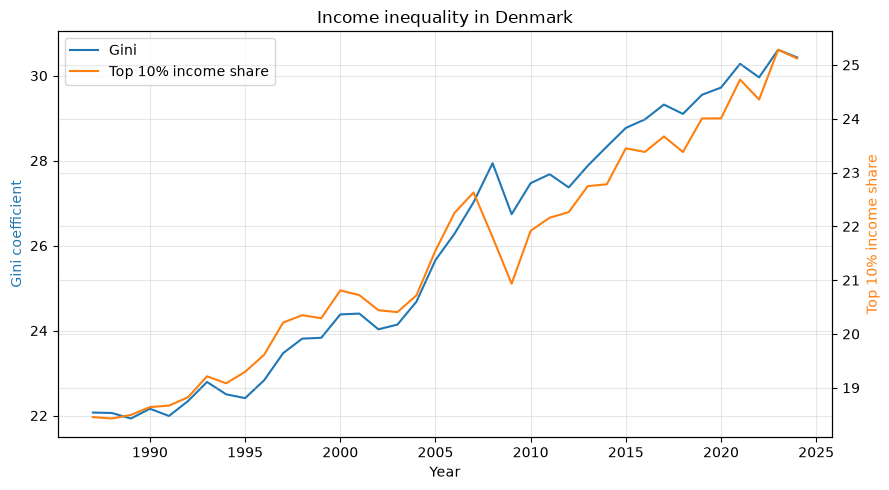

In [4]:
# We merge by year, calulate the correlation and plot the gini coefficient and top 10% income share in the same figure



deciles_columns = [column for column in deciles_table.columns if column != "ÅR"]
deciles_table["Top 10% income share"] = (deciles_table["10. decil"] / deciles_table.iloc[:, 1:11].sum(axis = 1) * 100) 

merged_table = pd.merge(gini_table, deciles_table, on = "ÅR")
correlation = merged_table["Gini"].corr(merged_table["Top 10% income share"])
print(f"Correlation over time: {correlation:.3f}")

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

line1 = ax1.plot(merged_table["ÅR"], merged_table["Gini"], color="tab:blue", label="Gini")

line2 = ax2.plot(merged_table["ÅR"], merged_table["Top 10% income share"], color="tab:orange", label="Top 10% income share" )

ax1.set_xlabel("Year")
ax1.set_ylabel("Gini coefficient", color="tab:blue")
ax2.set_ylabel("Top 10% income share", color="tab:orange")
ax1.set_title("Income inequality in Denmark")
ax1.legend(line1 + line2, [line.get_label() for line in line1 + line2], loc = "upper left")
fig.tight_layout()
plt.show()


From this, it is clear that the two measures largely tell the same story, which is that inequality in Denmark has rissen sinsce 1987. The large correlation between the two (0,982) futhermore, indicate that the two meassures are cloesly related.  

### 1.2 linear and quadratic prediction of the gini coefficient 
we let t be the number of years since 1987. We estimate a linear and a quadratic model by minimizing the squared prediciton errors with scipy.optimize.minimize. We then compare it to the build in method numpy.polyfit


In [ ]:

from models import ( linear_prediction, quadratic_prediction, linear_error, quadratic_error)

gini_table["ÅR"] = pd.to_numeric(gini_table["ÅR"])
gini_table["Gini"] = pd.to_numeric(gini_table["Gini"])


t = gini_table["ÅR"].to_numpy() - 1987
y = gini_table["Gini"].to_numpy()

#now we calculate the betas wich minimize the error for the two models using scipy.otimize#

linear_initial_beta = [0, 0]
quadratic_initial_beta = [0, 0, 0]
linear_result = minimize(linear_error, linear_initial_beta, args=(t, y))
quadratic_result = minimize(quadratic_error, quadratic_initial_beta, args=(t, y))

#we print the the beta values for wich the error is minimized.

results_table = pd.DataFrame([ 
    ["Linear", linear_result.x[0], linear_result.x[1], "-"],
    ["Quadratic", quadratic_result.x[0], quadratic_result.x[1], quadratic_result.x[2]]
], columns=["model", "Beta 0", "Beta 1", "Beta 2"])

display(results_table.style.hide(axis="index"))


#we solve the same minimize problem with np.polfit to compare the results.

linear_coefficients = np.polyfit(t, y, 1)
quadratic_coefficients = np.polyfit(t, y, 2)

polyfit_table = pd.DataFrame([
    ["Linear", linear_coefficients[1], linear_coefficients[0], "-"],
    ["Quadratic",quadratic_coefficients[2], quadratic_coefficients[1], quadratic_coefficients[0]],
    
], columns=["model", "Beta 0", "Beta 1", "Beta 2"])

display(polyfit_table.style.hide(axis="index"))



defining the linear and quadratic models
calculating the error from the two models
now we calculate the betas wich minimize the error for the two models using scipy.otimize
we print the the beta values for wich the error is minimized.


model,Beta 0,Beta 1,Beta 2
Linear,21.042754,0.263550,-
Quadratic,21.304187,0.219976,0.001178


we solve the same minimize problem with np.polfit and compare the results.


model,Beta 0,Beta 1,Beta 2
Linear,21.042753,0.263550,-
Quadratic,21.304200,0.219975,0.001178


In [6]:
print("we now seek to predict the Gini coefficient for 2030 and 2040 with the two models.")

t_future = np.array([2030, 2040]) - 1987
linear_predictions = linear_prediction(linear_result.x, t_future)
quadratic_predictions = quadratic_prediction(quadratic_result.x, t_future)

predictions = pd.DataFrame({
    "Year": [2030, 2040], 
    "Linear": linear_predictions,
    "Quadratic": quadratic_predictions
})
display(predictions.style.hide(axis="index"))



we now seek to predict the Gini coefficient for 2030 and 2040 with the two models.


Year,Linear,Quadratic
2030,32.375386,32.940671
2040,35.010882,36.270997


we plot the results of the predictions


<function matplotlib.pyplot.show(close=None, block=None)>

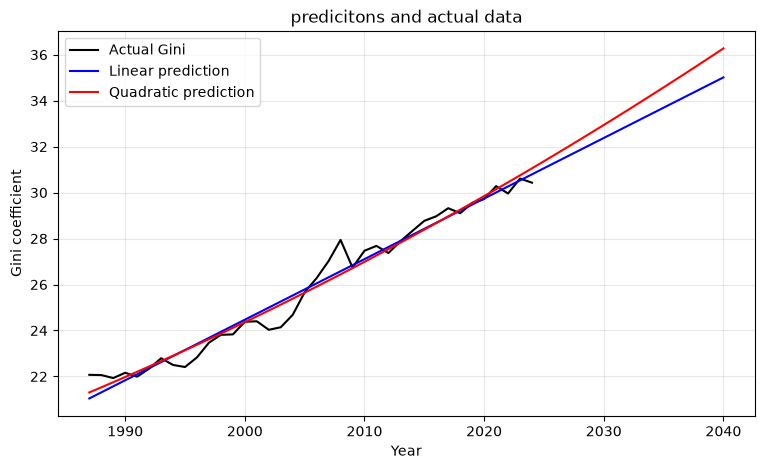

In [7]:
print("we plot the results of the predictions")

years = np.arange(1987, 2041)
t_all = years - 1987

linear_all = linear_prediction(linear_result.x, t_all)
quadratic_all = quadratic_prediction(quadratic_result.x, t_all)

plt.plot(
    gini_table["ÅR"],
    gini_table["Gini"],
    color="black",
    label="Actual Gini"
)

plt.plot(
    years, 
    linear_all,
    color="blue",
    label="Linear prediction"
)

plt.plot(
    years, 
    quadratic_all,
    color="red",
    label="Quadratic prediction"
)


plt.xlabel("Year")
plt.ylabel("Gini coefficient")
plt.title("predicitons and actual data")
plt.legend()
plt.show

Is it clear that the Quadratic function fits historical observation sligtly better, this is beacuse is is able to capture curvature, while the linear model impose a constant yearly change. The estimates are relativly close in 2030 but diverge more in 2040. Neither of the two meassures should be interpreted as a highly reliable prediction, since neither of them capture thigs like, future policy change and changes in economic regimes. futhermore it is evident that both the manual method and the np.polyfit function approximately get the same results. 

## 1.3 Municipalities

We now examine income inequality across Danish municipalities. We compare the Gini coefficient with the income share of the top 10 percent, identify the most and least unequal municipalities, and examine how municipal inequality has changed over time.

In [ ]:
# Remove the national total
gini_mun = ifor41[ifor41["KOMMUNEDK"] != "Hele landet"].copy()
decile_mun = ifor32[ifor32["KOMMUNEDK"] != "Hele landet"].copy()

gini_mun["INDHOLD"] = pd.to_numeric(gini_mun["INDHOLD"])
decile_mun["INDHOLD"] = pd.to_numeric(decile_mun["INDHOLD"])

# Create a decile table
decile_mun = decile_mun.pivot(
    index=["KOMMUNEDK", "TID"],
    columns="DECILGEN",
    values="INDHOLD"
).reset_index()

deciles = [f"{i}. decil" for i in range(1, 11)]

decile_mun["Top 10 share"] = (
    decile_mun["10. decil"] /
    decile_mun[deciles].sum(axis=1) * 100
)

# Merge Gini and top 10 percent income share
mun_data = pd.merge(
    gini_mun[["KOMMUNEDK", "TID", "INDHOLD"]],
    decile_mun[["KOMMUNEDK", "TID", "Top 10 share"]],
    on=["KOMMUNEDK", "TID"],
    validate="1:1"
)

mun_data.columns = ["Municipality", "Year", "Gini", "Top 10 share"]
mun_data["Year"] = pd.to_numeric(mun_data["Year"])

### Correlation across municipalities

First, we examine whether the Gini coefficient and the income share of the top 10 percent provide a similar picture of inequality across municipalities. The correlation is calculated using the most recent year in the data.

In [ ]:
latest_year = mun_data["Year"].max()
latest = mun_data[mun_data["Year"] == latest_year].copy()

correlation_mun = latest["Gini"].corr(latest["Top 10 share"])

print(f"Latest year: {latest_year}")
print(f"Correlation across municipalities: {correlation_mun:.3f}")
print(f"Correlation over time for Denmark: {correlation:.3f}")

Latest year: 2024
Correlation across municipalities: 0.975
Correlation over time for Denmark: 0.982


The correlation across municipalities is 0.975, which is very close to the correlation over time of 0.982. Both correlations are very high and positive, which means that municipalities with a high Gini coefficient also tend to have a high share of income going to the richest 10 percent. The two measures therefore give a very similar picture of inequality. 

### Most and least unequal municipalities

Next, we rank the municipalities according to their Gini coefficient in the most recent year. The 10 municipalities with the highest Gini coefficients are compared with the 10 municipalities with the lowest Gini coefficients.

In [ ]:
most = latest.nlargest(10, "Gini").copy()
least = latest.nsmallest(10, "Gini").copy()

print("10 most unequal municipalities:")
display(most[["Municipality", "Gini"]])

print("10 least unequal municipalities:")
display(least[["Municipality", "Gini"]])

10 most unequal municipalities:


,Municipality,Gini
3435,Gentofte,49.04
3453,Rudersdal,47.31
3493,Vejen,46.32
3452,Hørsholm,40.07
3442,Lyngby-Taarbæk,39.28
3431,Frederiksberg,36.54
3430,København,34.97
3511,Aarhus,33.43
3449,Fredensborg,32.76
3450,Helsingør,30.55


10 least unequal municipalities:


,Municipality,Gini
3478,Faaborg-Midtfyn,23.77
3454,Egedal,23.85
3475,Bornholm,24.03
3464,Faxe,24.09
3458,Halsnæs,24.41
3505,Favrskov,24.41
3477,Assens,24.46
3514,Hedensted,24.58
3439,Albertslund,24.66
3506,Odder,24.70


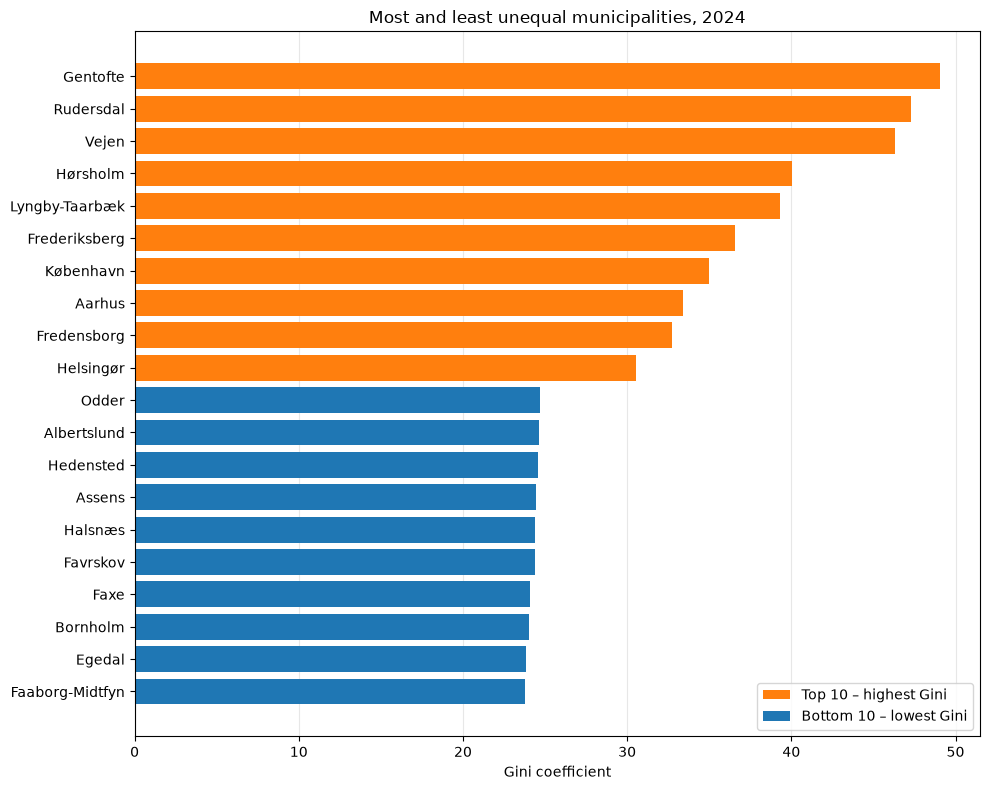

In [ ]:
most["Group"] = "Top 10"
least["Group"] = "Bottom 10"

ranking = pd.concat([most, least]).sort_values("Gini").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))

positions = np.arange(len(ranking))
top_mask = ranking["Group"] == "Top 10"
bottom_mask = ranking["Group"] == "Bottom 10"

ax.barh(
    positions[top_mask],
    ranking.loc[top_mask, "Gini"],
    color="tab:orange",
    label="Top 10 – highest Gini"
)

ax.barh(
    positions[bottom_mask],
    ranking.loc[bottom_mask, "Gini"],
    color="tab:blue",
    label="Bottom 10 – lowest Gini"
)

ax.set_yticks(positions)
ax.set_yticklabels(ranking["Municipality"])
ax.set_title(f"Most and least unequal municipalities, {latest_year}")
ax.set_xlabel("Gini coefficient")

ax.grid(True, axis="x", alpha=0.3)
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

The figure shows that Gentofte, Rudersdal and Vejen are among the most unequal municipalities, followed by Hørsholm, Lyngby-Taarbæk, Frederiksberg and Copenhagen. At the other end, municipalities such as Faaborg-Midtfyn, Egedal, Bornholm and Faxe have much lower Gini coefficients.

A general pattern is that several municipalities around Copenhagen and some of the larger cities have relatively high inequality. However, Vejen stands out, since its Gini coefficient is much higher than most other municipalities. This suggests that there could be extreme incomes in small populations, that can have a large effect on the Gini coefficient in a municipality.


### Change in municipal inequality

Finally, we examine how the Gini coefficient has changed across municipalities between the first and the most recent year in the dataset. This allows us to identify the municipalities that have experienced the largest and smallest increases in income inequality.

In [ ]:
first_year = mun_data["Year"].min()

first = mun_data[mun_data["Year"] == first_year].copy()
last = mun_data[mun_data["Year"] == latest_year].copy()

change = pd.merge(
    first[["Municipality", "Gini"]],
    last[["Municipality", "Gini"]],
    on="Municipality",
    suffixes=("_first", "_last")
)

change["Change"] = change["Gini_last"] - change["Gini_first"]

largest = change.nlargest(10, "Change").copy()
smallest = change.nsmallest(10, "Change").copy()

print("Largest changes:")
display(largest[["Municipality", "Change"]])

print("Smallest changes:")
display(smallest[["Municipality", "Change"]])

Largest changes:


,Municipality,Change
63,Vejen,25.12
23,Rudersdal,18.26
5,Gentofte,17.94
12,Lyngby-Taarbæk,14.31
0,København,11.92
22,Hørsholm,11.68
19,Fredensborg,11.59
81,Aarhus,11.33
1,Frederiksberg,11.26
16,Vallensbæk,10.80


Smallest changes:


,Municipality,Change
61,Fanø,0.67
55,Ærø,2.35
34,Faxe,2.45
92,Læsø,2.60
45,Bornholm,2.72
48,Faaborg-Midtfyn,2.89
39,Sorø,2.92
38,Stevns,3.42
94,Mariagerfjord,3.67
76,Odder,3.77


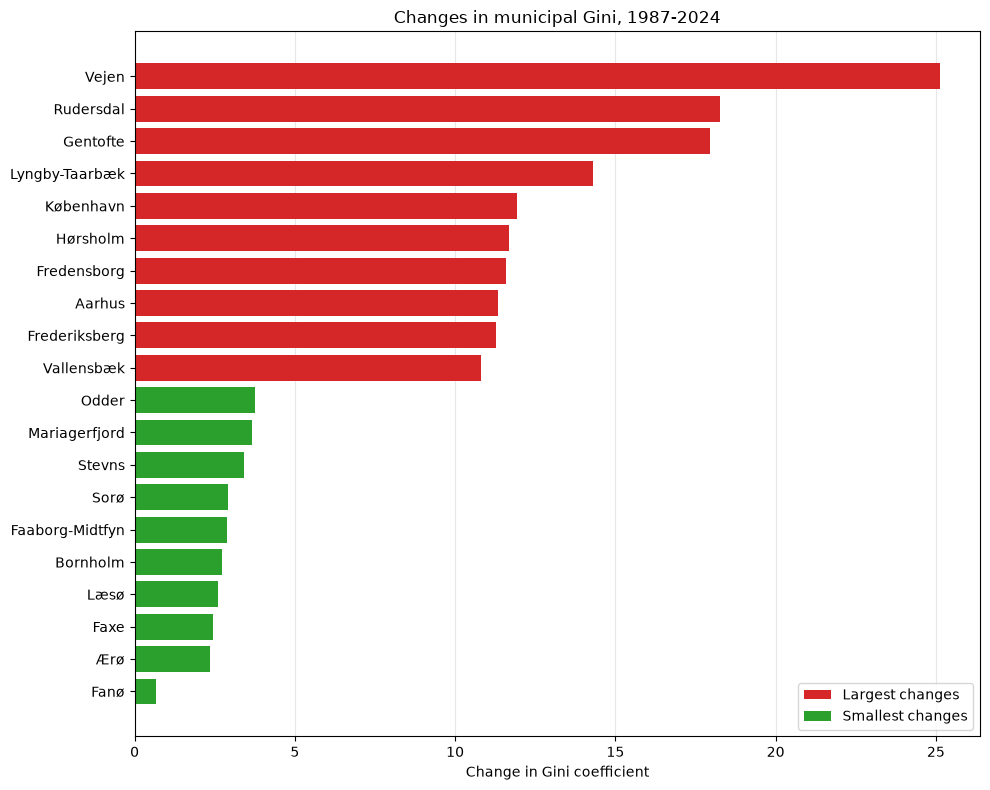

In [ ]:
largest["Group"] = "Largest changes"
smallest["Group"] = "Smallest changes"

change_plot = pd.concat([largest, smallest]).sort_values("Change").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))

positions = np.arange(len(change_plot))
largest_mask = change_plot["Group"] == "Largest changes"
smallest_mask = change_plot["Group"] == "Smallest changes"

ax.barh(
    positions[largest_mask],
    change_plot.loc[largest_mask, "Change"],
    color="tab:red",
    label="Largest changes"
)

ax.barh(
    positions[smallest_mask],
    change_plot.loc[smallest_mask, "Change"],
    color="tab:green",
    label="Smallest changes"
)

ax.set_yticks(positions)
ax.set_yticklabels(change_plot["Municipality"])
ax.set_title(f"Changes in municipal Gini, {first_year}-{latest_year}")
ax.set_xlabel("Change in Gini coefficient")

ax.grid(True, axis="x", alpha=0.3)
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

The largest increase in the Gini coefficient is found in Vejen, followed by Rudersdal, Gentofte and Lyngby-Taarbæk. Copenhagen, Hørsholm, Fredensborg, Aarhus and Frederiksberg have also experienced relatively large increases. Vejen again stands out with a particularly large change, while the change in Fanø is very small.

Overall, the results show that the development of income inequality has not been identical across Danish municipalities. Some municipalities have experienced substantially larger increases in the Gini coefficient than others.

## 1.4 Extension: education and municipal inequality

As an extension, we examine the relationship between education and income inequality across municipalities. We measure education as the share of residents with a long higher education or a PhD/research education and compare this measure with the municipal Gini coefficient.

In [ ]:
api_edu = DstApi("LIGEUB1")

params_edu = {
    "table": "LIGEUB1",
    "format": "BULK",
    "lang": "da",
    "variables": [
        {"code": "BOPOMR", "values": ["*"]},
        {"code": "HERKOMST", "values": ["*"]},
        {"code": "HFUDD", "values": ["*"]},
        {"code": "ALDER", "values": ["*"]},
        {"code": "KØN", "values": ["*"]},
        {"code": "Tid", "values": ["2024"]}
    ]
}

education = api_edu.get_data(params=params_edu)

education["INDHOLD"] = pd.to_numeric(
    education["INDHOLD"],
    errors="coerce"
)

# Keep totals for origin, age and sex
education = education[
    (education["HERKOMST"] == "I alt") &
    (education["ALDER"] == "Alder i alt") &
    (education["KØN"] == "I alt")
]

# Total population
total = education[
    education["HFUDD"] == "I alt"
][["BOPOMR", "INDHOLD"]]

total.columns = ["Municipality", "Total"]

# Long higher education and PhD/research education
high = education[
    education["HFUDD"].isin([
        "H70 Lange videregående uddannelser, LVU",
        "H80 Ph.d. og forskeruddannelser"
    ])
]

high = high.groupby("BOPOMR")["INDHOLD"].sum().reset_index()
high.columns = ["Municipality", "High education"]

# Calculate the share with high education
edu = pd.merge(total, high, on="Municipality")

edu["High education share"] = (
    edu["High education"] / edu["Total"] * 100
)

# Merge education data with municipal Gini
extension = pd.merge(
    latest[["Municipality", "Gini"]],
    edu[["Municipality", "High education share"]],
    on="Municipality"
)

corr_edu = extension["Gini"].corr(
    extension["High education share"]
)

print(
    f"Correlation between high education share and Gini: "
    f"{corr_edu:.3f}"
)

Correlation between high education share and Gini: 0.674


### Education and income inequality

The scatter plot below illustrates the relationship between the share of highly educated residents and the municipal Gini coefficient. A linear fitted line is included to make the overall relationship easier to see.

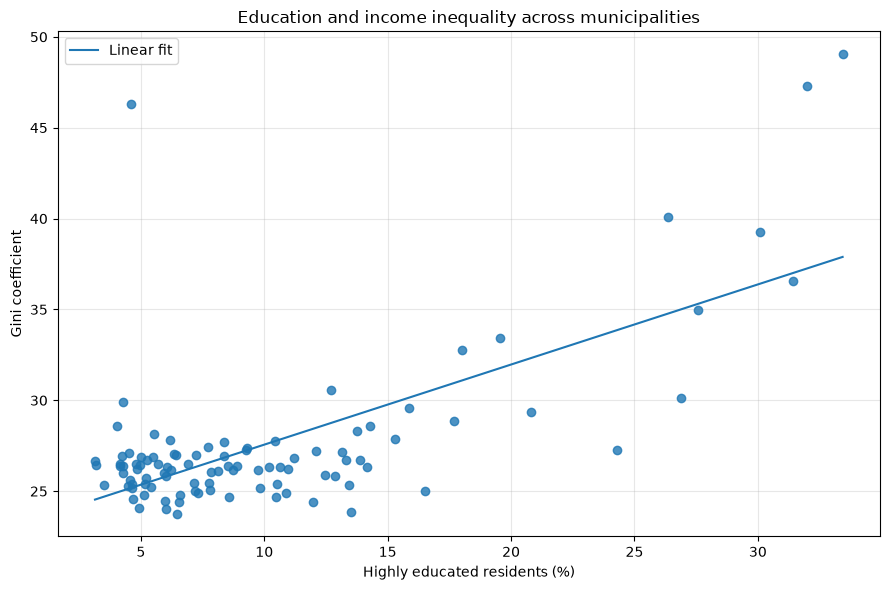

In [ ]:
x = extension["High education share"]
y = extension["Gini"]

a, b = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 200)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    x,
    y,
    alpha=0.8
)

ax.plot(
    x_line,
    a * x_line + b,
    label="Linear fit"
)

ax.set_xlabel("Highly educated residents (%)")
ax.set_ylabel("Gini coefficient")
ax.set_title("Education and income inequality across municipalities")

ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

The correlation is 0.674, which shows a positive relation. Municipalities with a larger share of highly educated people therefore tend to have higher Gini coefficients. The figure also shows this positive trend, although there are some outliers. This may reflect that highly educated people often have higher incomes, which can increase income differences within a municipality. 

However, this relationship is descriptive and should not be interpreted as causal. A higher share of highly educated residents does not necessarily cause higher income inequality. Other differences between municipalities, such as industry composition, housing markets, age structure and the presence of very high-income residents, may influence both education levels and income inequality.

# Exercise 2: simulating the income distribution

The model is implemented in the module `incomesim.py`, which is imported below. This notebook calls the functions in the module, shows the figures and comments on the results.

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import incomesim as sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Exercise 2.1

All parameters are defined at the top of `incomesim.py`

In [ ]:
rng = np.random.default_rng(sim.seed)

psi, education_level_i, S_e_i, uniforms = sim.draw_shocks(rng)

print('All global variables and shocks are defined')
print(f'mean value of psi: {psi.mean():.2f}')

All global variables and shocks are defined
mean value of psi: 1.00


## Excercise 2.2

### 2.2.1

Before using the simulation we check it: the education shares should match $p_e$, and the unemployment rate should be close to the steady-state value $\sigma/(\sigma+\lambda)$.

In [ ]:
print('Comparing education shares to p_e:')
sim.check_education_shares(education_level_i)

Comparing education shares to p_e:
Share short  0.3996 (target 0.4)
Share medium 0.3503 (target 0.35)
Share long   0.2501 (target 0.25)


In [ ]:
employed = sim.simulate_employment(S_e_i, uniforms)

t_values = [1, 5, 8, 10, 20, 30, 40, sim.n_years - 1]
sim.check_unemployment_rate(employed, S_e_i, t_values)

Comparing unemployment rate to theoretical:
t = 1 (age 19): unemployment rate = 1.0000
t = 5 (age 23): unemployment rate = 0.3525
t = 8 (age 26): unemployment rate = 0.0888
t = 10 (age 28): unemployment rate = 0.0784
t = 20 (age 38): unemployment rate = 0.0771
t = 30 (age 48): unemployment rate = 0.0757
t = 40 (age 58): unemployment rate = 0.0767
t = 46 (age 64): unemployment rate = 0.0758

Theoretical steady-state unemployment rate: sigma/(sigma+lam) = 0.0769


The unemployment rate is high in the first years because everybody enters the labor market as unemployed but then converges towards the steady state.

### 2.2.2

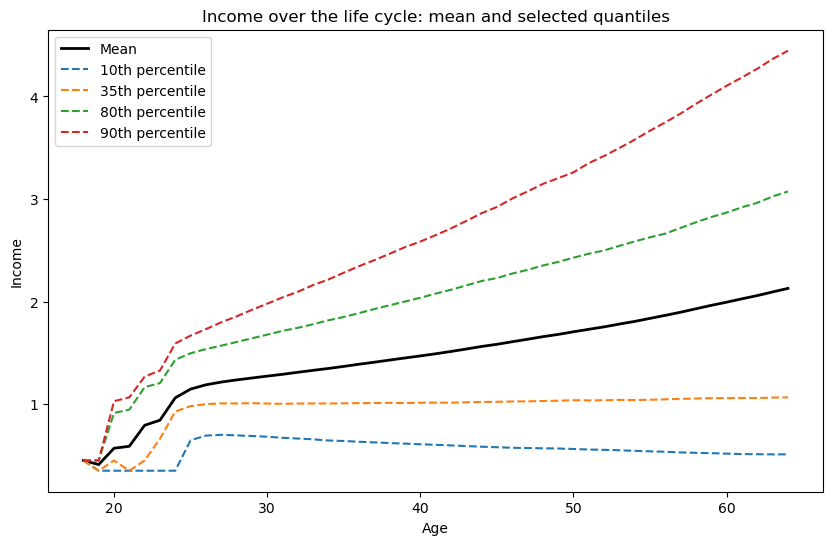

In [ ]:
mean_income = income.mean(axis=0)

p10 = np.percentile(income, 10, axis=0)
p35 = np.percentile(income, 35, axis=0)
p80 = np.percentile(income, 80, axis=0)
p90 = np.percentile(income, 90, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(sim.ages, mean_income, label='Mean', color='black', linewidth=2)
plt.plot(sim.ages, p10, label='10th percentile', linestyle='--')
plt.plot(sim.ages, p35, label='35th percentile', linestyle='--')
plt.plot(sim.ages, p80, label='80th percentile', linestyle='--')
plt.plot(sim.ages, p90, label='90th percentile', linestyle='--')

plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Income over the life cycle: mean and selected quantiles')
plt.legend()
plt.show()

The figure shows the mean income and four percentiles over the life cycle.

### 2.2.3

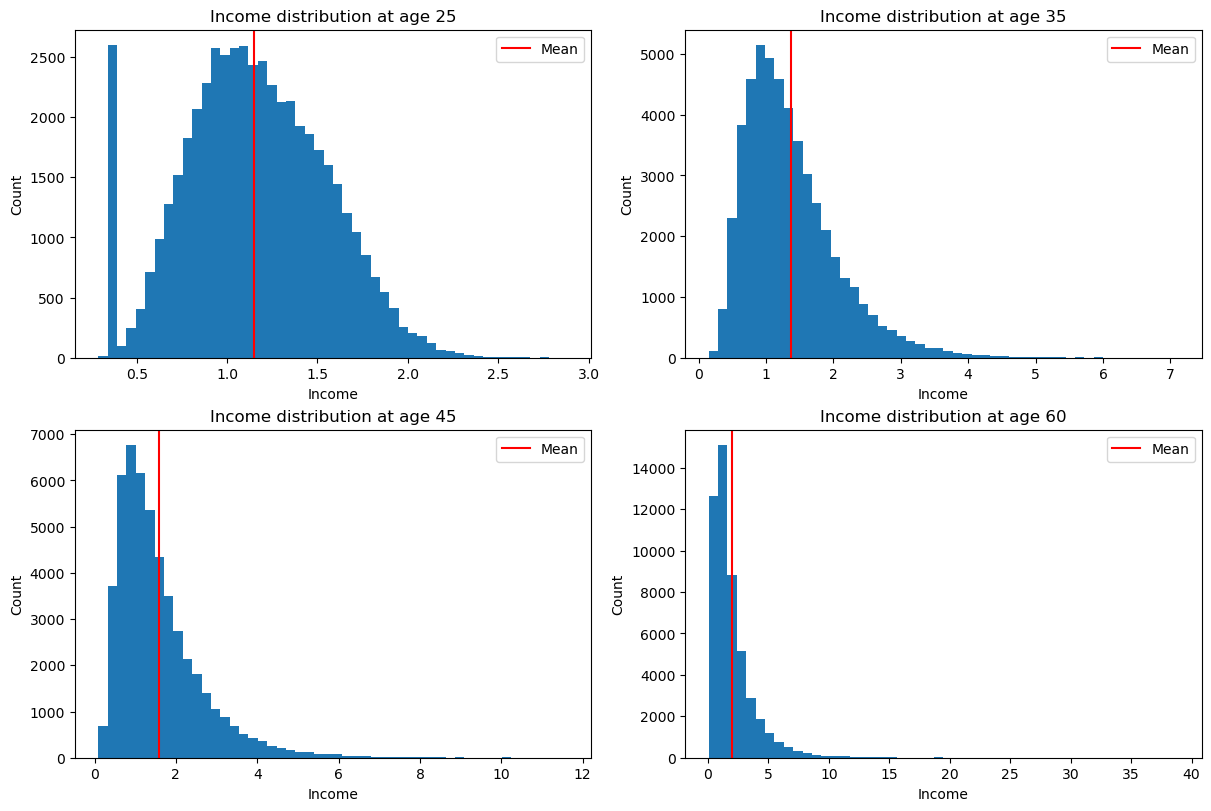

In [ ]:
ages_plot = [25, 35, 45, 60]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
axes = axes.flatten()

for idx, age in enumerate(ages_plot):
    t = age - sim.age_start  # convert age to the period index
    axes[idx].hist(income[:, t], bins=50)
    axes[idx].axvline(income[:, t].mean(), color='red', label='Mean')
    axes[idx].set_title(f'Income distribution at age {age}')
    axes[idx].set_xlabel('Income')
    axes[idx].set_ylabel('Count')
    axes[idx].legend()

plt.show()

The plot shows that as time passes, the histograms shrink in size. This
likely happens because the three groups each converge against individual
income levels. However, while the histograms shrink in size, the relative
difference between incomes, i.e. the level of inequality, seems to
increase.

## Exercise 2.3

The function `gini_coefficient` is tested on two distributions where the
answer is known: the uniform distribution on $[0,1]$, where the Gini
coefficient is exactly $1/3$, and the lognormal distribution, where it is
$2\Phi(s/\sqrt{2})-1$.

In [ ]:
gini_full_sample = sim.gini_coefficient(income.flatten())
print(f'Gini coefficient (FULL SAMPLE, all ages pooled): '
      f'{gini_full_sample:.4f}')

# uniform distribution
uniform_sample = rng.uniform(0, 1, 100_000)
gini_uniform = sim.gini_coefficient(uniform_sample)
print(f'Gini coefficient (UNIFORM TEST): {gini_uniform:.4f} '
      f'(theoretical: {1/3:.4f})')

# lognormal distribution
s = 2
lognormal_sample = rng.lognormal(0, s, size=100_000)
gini_lognormal = sim.gini_coefficient(lognormal_sample)
theoretical_lognormal = sim.gini_lognormal(s)
print(f'Gini coefficient (LOGNORMAL TEST, s={s}): {gini_lognormal:.4f} '
      f'(theoretical: {theoretical_lognormal:.4f})')

Gini coefficient (FULL SAMPLE, all ages pooled): 0.3742
Gini coefficient (UNIFORM TEST): 0.3339 (theoretical: 0.3333)
Gini coefficient (LOGNORMAL TEST, s=2): 0.8438 (theoretical: 0.8427)


### 2.3.1

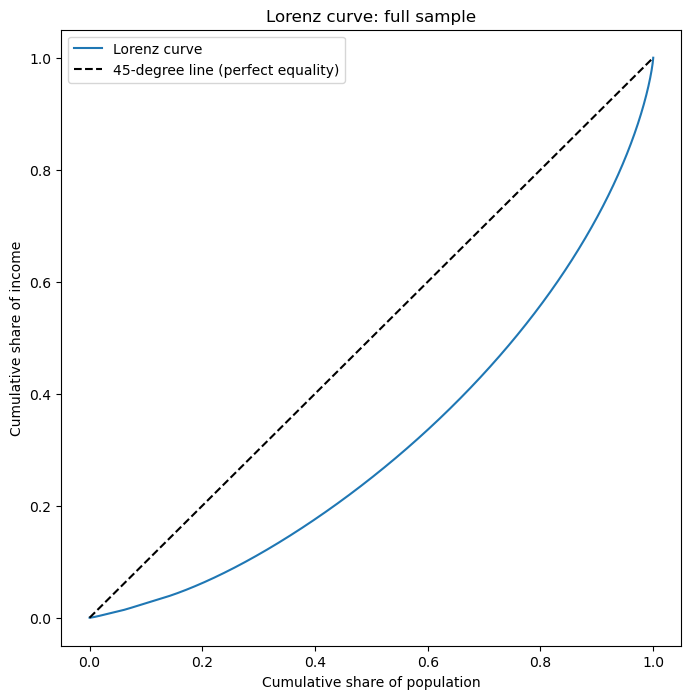

In [ ]:
population_share, cumulative_income_share = sim.lorenz_curve(income.flatten())

plt.figure(figsize=(8, 8))
plt.plot(population_share, cumulative_income_share, label='Lorenz curve')
plt.plot([0, 1], [0, 1], label='45-degree line (perfect equality)',linestyle='--', color='black')

plt.xlabel('Cumulative share of population')
plt.ylabel('Cumulative share of income')
plt.title('Lorenz curve: full sample')
plt.legend()
plt.show()

### 2.3.2

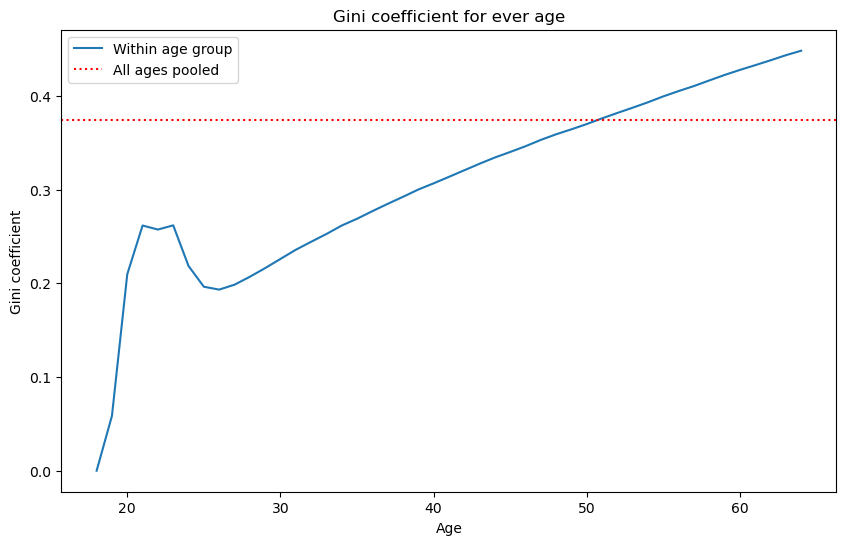

In [ ]:
gini_by_age_baseline = sim.gini_by_age(income)

plt.figure(figsize=(10, 6))
plt.plot(sim.ages, gini_by_age_baseline, label='Within age group')
plt.axhline(gini_full_sample, color='red', linestyle=':', label='All ages pooled')
plt.xlabel('Age')
plt.ylabel('Gini coefficient')
plt.title('Gini coefficient for ever age')
plt.legend()
plt.show()

The graph shows that inequality increases with age due to differences in human capital accumulation. Thus, for some age groups the Gini coefficient is larger and for some smaller than for the entire population.

## 2.4
All four scenarios reuse `simulate_employment` and `simulate_income` as in the baseline case, but in each of the scenarios, parameter values are changed.

In [ ]:
# No educational differences:
S_e_avg, h_e0_avg, delta_e_avg = sim.average_education_parameters()
S_e_i_no_education = np.full(sim.N, S_e_avg)

employed_no_education = sim.simulate_employment(S_e_i_no_education, uniforms)
income_no_education, _ = sim.simulate_income(S_e_i_no_education, employed_no_education, psi, 
                                             education_level_i,h_e0=h_e0_avg, delta_e=delta_e_avg)

# No shocks to human capital: 
psi_no_shocks = np.ones((sim.N, sim.n_years))
income_no_shocks, _ = sim.simulate_income(S_e_i, employed, psi_no_shocks, education_level_i)

# No depreciation while unemployed:
income_no_depreciation, _ = sim.simulate_income(S_e_i, employed, psi,education_level_i, delta=0.0)

# No unemployment:
employed_no_unemployment = sim.employment_always_employed(S_e_i)
income_no_unemployment, _ = sim.simulate_income(
    S_e_i, employed_no_unemployment, psi, education_level_i)

print('Simulated the four scenarios')

Simulated the four scenarios


In [ ]:
scenarios = {'Baseline': income,
             'No educational differences': income_no_education,
             'No human capital shocks': income_no_shocks,
             'No depreciation while unemployed': income_no_depreciation,
             'No unemployment': income_no_unemployment}

print(f'{"scenario":<34s}{"pooled":>9s}')
for name, y in scenarios.items():
    pooled = sim.gini_coefficient(y.flatten())
    print(f'{name:<34s}{pooled:>9.4f}')

scenario                             pooled
Baseline                             0.3742
No educational differences           0.3256
No human capital shocks              0.2773
No depreciation while unemployed     0.3792
No unemployment                      0.3676


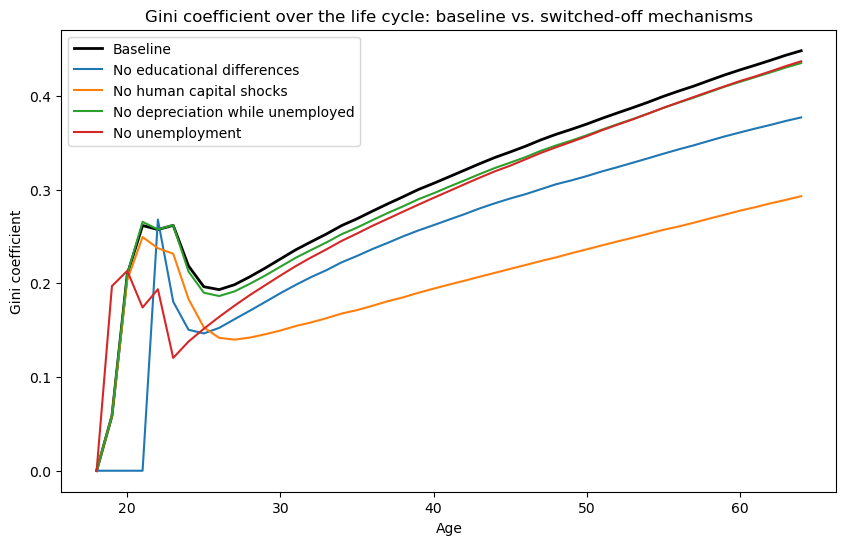

In [ ]:
plt.figure(figsize=(10, 6))
for name, y in scenarios.items():
    if name == 'Baseline':
        plt.plot(sim.ages, sim.gini_by_age(y), label=name, color='black',
                 linewidth=2)
    else:
        plt.plot(sim.ages, sim.gini_by_age(y), label=name)

plt.xlabel('Age')
plt.ylabel('Gini coefficient')
plt.title('Gini coefficient over the life cycle: baseline vs. '
          'switched-off mechanisms')
plt.legend()
plt.show()

In the case of no depreciation of human capital while unemployed (green line), the results show that the Gini coefficient across the entire population increases, while it is lower than or equal to the baseline case within every age group. This is likely caused by the increased difference between younger and older age groups, since the lack of depreciation means older workers now simply accumulate more human capital on average.

## Exercise 2.5: Risk of injury

To mimic the fact that less educated people more often than highly educated people do physical work, we augment the model by adding a risk of injury while working. In this case, human capital depreciates at a faster rate, but the worker keeps the salary from just before the injury. Note that once the worker returns to the labour market, they are again compensated relative to their level of human capital.

Since employment now has three states, this is a separate simulation function in the module: `simulate_income_injury`.

We set delta_injury = 0.1, the chance of recovery to 0.95, and the risk of injury to (0.05, 0.02, 0.01) by education, so that the short-educated face the highest risk.

In [ ]:
p_injury_e = np.array([0.05, 0.02, 0.01]) # chance of getting injured
p_recovery = 0.95 # change to recover from injury
delta_injury = 0.1 # depreciation while injured

uniforms_injury = rng.uniform(0.0, 1.0, size=(sim.N, sim.n_years))

income_injury, human_capital_injury = sim.simulate_income_injury(
    S_e_i, uniforms_injury, psi, education_level_i,
    p_injury_e=p_injury_e, p_recovery=p_recovery,
    delta_injury=delta_injury)

gini_full_injury = sim.gini_coefficient(income_injury.flatten())
print(f'Gini coefficient (injury risk extension, full sample): 'f'{gini_full_injury:.4f}')
print(f'Gini coefficient (baseline, full sample): 'f'{gini_full_sample:.4f}')

Gini coefficient (injury risk extension, full sample): 0.3784
Gini coefficient (baseline, full sample): 0.3742


We find that the addition of potential injury increases inequality, however only slightly.

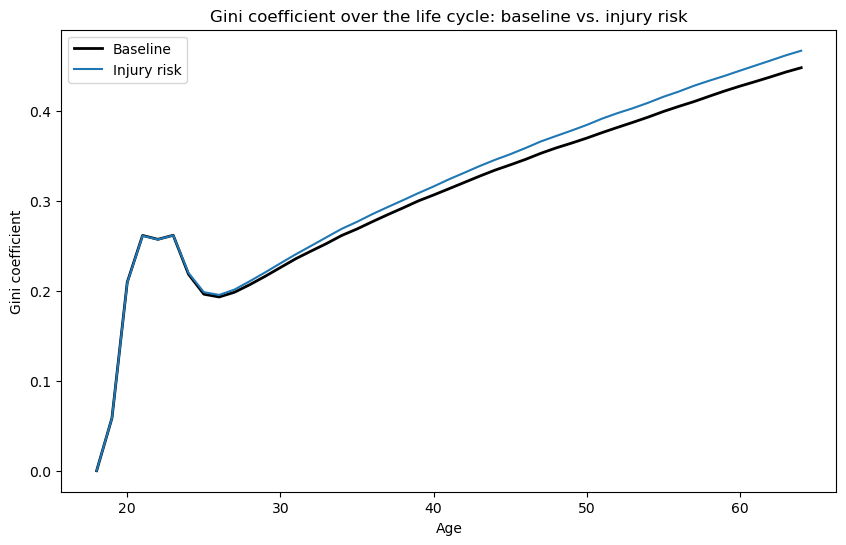

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(sim.ages, gini_by_age_baseline, label='Baseline', color='black',
         linewidth=2)
plt.plot(sim.ages, sim.gini_by_age(income_injury), label='Injury risk')

plt.xlabel('Age')
plt.ylabel('Gini coefficient')
plt.title('Gini coefficient over the life cycle: baseline vs. injury risk')
plt.legend()
plt.show()

In [ ]:
# mean income by education, with and without injury risk
print(f'{"education":<10s}{"baseline":>10s}{"injury":>10s}{"pct":>8s}')
for e in range(3):
    keep = education_level_i == e
    y_base = income[keep].mean()
    y_injury = income_injury[keep].mean()
    pct = 100 * (y_injury / y_base - 1)
    print(f'{sim.educations[e]:<10s}{y_base:>10.4f}{y_injury:>10.4f}'
          f'{pct:>8.2f}')

education   baseline    injury     pct
short         1.0177    0.9180   -9.79
medium        1.4534    1.3904   -4.33
long          2.1777    2.1209   -2.61


Calculting the mean income for each education level in both cases shows that all levels of education are affected negatively by the introduction of risk of injury due to less human capital accumulation. However, it shows that individuals with short education are affected the most, which makes sense as they are the most prone to injuries.